## 1. Binary classification
adalah jenis klasifikasi paling sederhana di mana data dibagi menjadi dua kategori

In [64]:
#Binary classification using LightGBM
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score as ras
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')


In [65]:
df = pd.read_csv('../../0.Dataset/diabetes for clasification.csv')
df.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [66]:
df.shape

(768, 9)

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [68]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


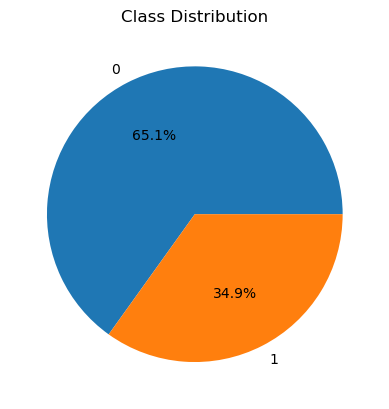

In [69]:
temp = df['Outcome'].value_counts()
plt.pie(temp.values,labels=temp.index.values,autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

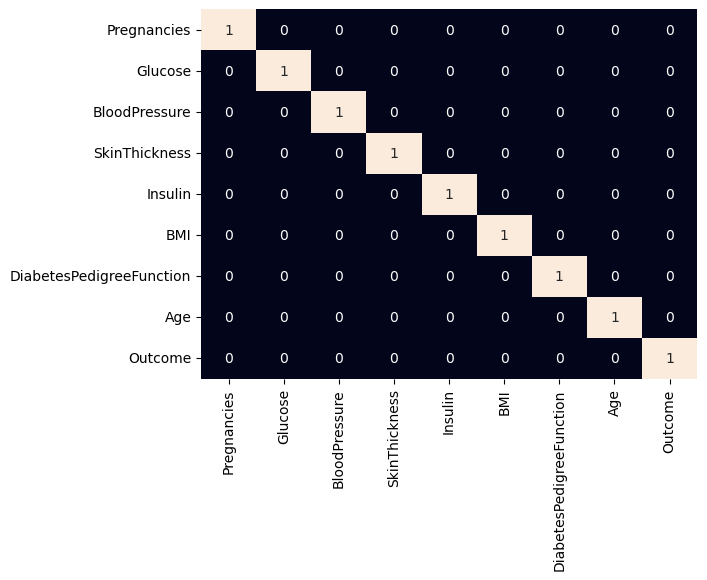

In [70]:
sns.heatmap(df.corr()>0.7,cbar=False,annot=True)
plt.show()

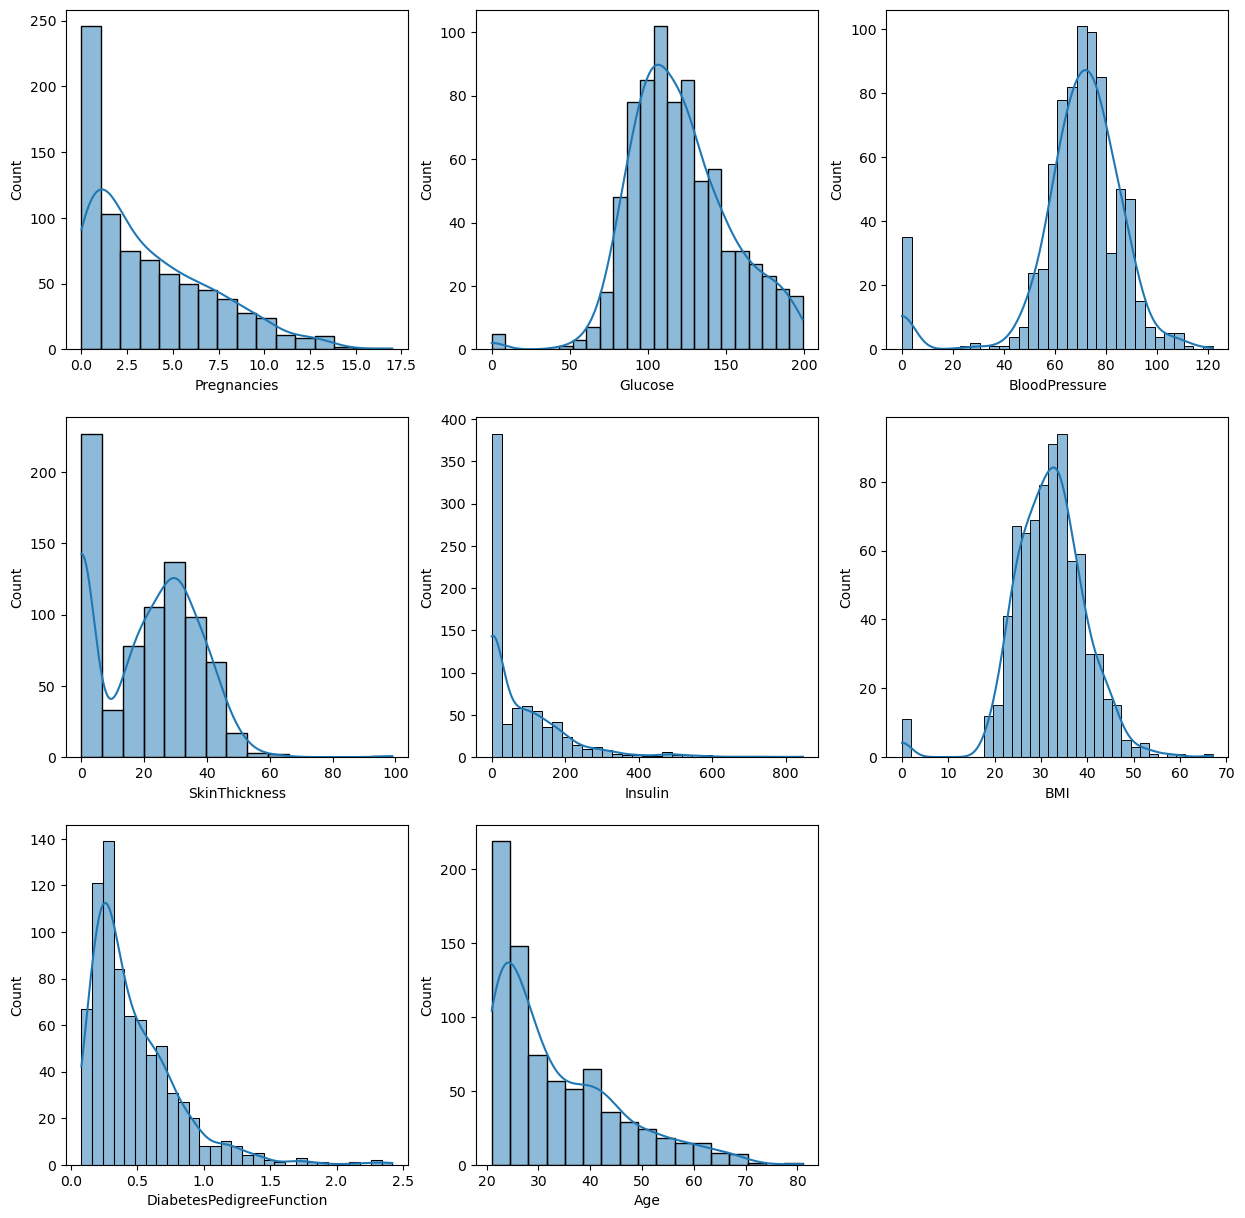

In [71]:
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

plt.figure(figsize=(15,15))
for col in num_cols:
    plt.subplot(3,3,num_cols.index(col)+1)
    sns.histplot(df[col],kde=True)
plt.show()

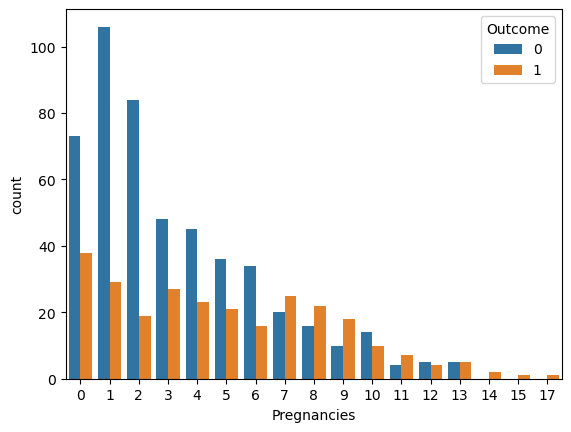

In [72]:
sns.countplot(data=df,x='Pregnancies',hue='Outcome')
plt.show()

In [73]:
features = df.drop('Outcome',axis=1)
target = df['Outcome']

X_train,X_val,Y_train,Y_val = train_test_split(features,target,test_size=0.2,random_state=42)

In [74]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [75]:
train_data = lgb.Dataset(X_train,label=Y_train)
test_data = lgb.Dataset(X_val,label=Y_val,reference=train_data)

In [76]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

num_round = 100
bst = lgb.train(params,train_data,num_round,valid_sets=[test_data],
                callbacks=[lgb.early_stopping(stopping_rounds=10)])
bst

[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000867 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 668
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

In [77]:
y_train = bst.predict(X_train)
y_val = bst.predict(X_val)

y_train_class = (y_train > 0.5).astype(int)
y_val_class = (y_val > 0.5).astype(int)

print("Training ROC-AUC: ", ras(Y_train,y_train))
print("Validation ROC-AUC: ", ras(Y_val, y_val))

Training ROC-AUC:  0.9291559832812335
Validation ROC-AUC:  0.8301193755739211


## 2. Multiclass classification

In [78]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix


In [79]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [80]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

### 1. Decision Tree Classifier

Decision Tree Accuracy: 0.9777777777777777


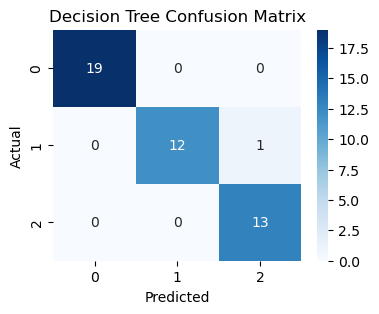

In [81]:
from sklearn.tree import DecisionTreeClassifier

dtree = DecisionTreeClassifier(max_depth=2,random_state=42)
dtree.fit(X_train,y_train)
dtree_preds = dtree.predict(X_test)
dtree_acc = accuracy_score(y_test,dtree_preds)
dtree_cm = confusion_matrix(y_test,dtree_preds)

print(f"Decision Tree Accuracy: {dtree_acc}")
plt.figure(figsize=(4, 3))
sns.heatmap(dtree_cm, annot=True, cmap="Blues", fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 2. Support Vector Machine(SVM) Classifier

SVM Accuracy: 1.0


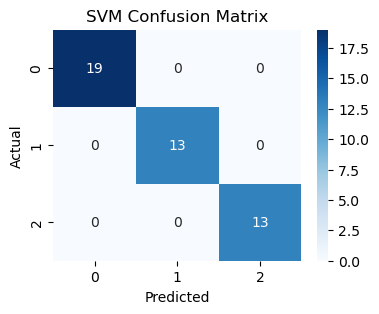

In [82]:
from sklearn.svm import SVC

svm = SVC(kernel='linear',C=1,random_state=42)
svm.fit(X_train,y_train)
svm_preds = svm.predict(X_test)
svm_acc = accuracy_score(y_test,svm_preds)
svm_cm = confusion_matrix(y_test,svm_preds)

print(f"SVM Accuracy: {svm_acc}")
plt.figure(figsize=(4, 3))
sns.heatmap(svm_cm, annot=True, cmap="Blues", fmt="d")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 3. K-Nearest Neighbors(KNN) Classifiers

KNN Accuracy: 1.0


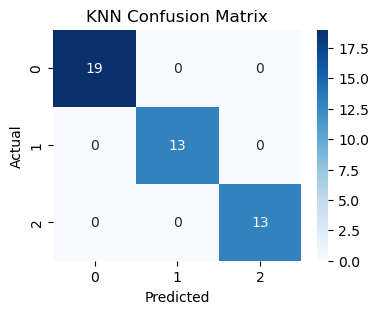

In [83]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,y_train)
knn_preds = knn.predict(X_test)
knn_acc = accuracy_score(y_test,knn_preds)
knn_cm = confusion_matrix(y_test,knn_preds)

print("KNN Accuracy:", knn_acc)

plt.figure(figsize=(4, 3))
sns.heatmap(knn_cm, annot=True, cmap="Blues", fmt="d")
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 4. Naive Bayes Classifier

Naive Bayes Accuracy: 0.9777777777777777


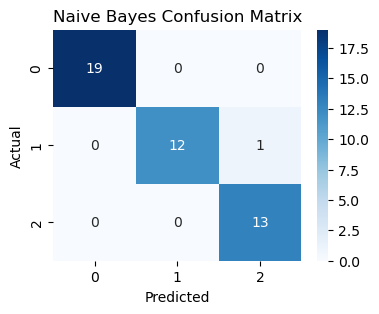

In [84]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train,y_train)
nb_preds = nb.predict(X_test)
nb_acc = accuracy_score(y_test,nb_preds)
nb_cm = confusion_matrix(y_test,nb_preds)

print("Naive Bayes Accuracy:", nb_acc)

plt.figure(figsize=(4, 3))
sns.heatmap(nb_cm, annot=True, cmap="Blues", fmt="d")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()